In [8]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset

class BrainTumor2DSliceDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_files = sorted(os.listdir(image_dir))
        self.mask_files = sorted(os.listdir(mask_dir))
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image = np.load(os.path.join(self.image_dir, self.image_files[idx])).astype(np.float32)  # (128,128,4)
        image = image[:, :, :3]  # Select first 3 channels to match model input


        mask = np.load(os.path.join(self.mask_dir, self.mask_files[idx])).astype(np.float32)  # (128, 128, 4)
        mask = mask[:, :, 3]  # or 2 or 1, depending on which has tumor info
        mask = (mask > 0).astype(np.float32)
        mask = torch.from_numpy(mask)         # (128, 128)
        mask = mask.unsqueeze(0)  # Now (1, 128, 128)

        for i in range(4):
            print(f"Channel {i} unique values:", np.unique(sample_mask[:, :, i]))


        # Convert to torch tensors
        image = torch.from_numpy(image).permute(2, 0, 1)  # (3, 128, 128)

        if self.transform:
            image = self.transform(image)

        return image, mask


In [9]:
import torch

from torch.utils.data import DataLoader

from unet_model import UNet

import matplotlib.pyplot as plt

import numpy as np



# Corrected validation paths (removed leading slash)

val_images_path = "Brats_2D_Unet_Project/data/2d/val/images"

val_masks_path = "Brats_2D_Unet_Project/data/2d/val/masks"



# Load validation dataset

val_dataset = BrainTumor2DSliceDataset(val_images_path, val_masks_path)

val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)



# Load model with correct input/output channels to match checkpoint

model = UNet(in_channels=3, out_channels=1)

model.load_state_dict(torch.load("unet_model_brats.pth", map_location=torch.device('cpu')))

model.eval()



# Show one prediction

images, masks = next(iter(val_loader))

print("Mask shape:", masks.shape)
print("Unique values in mask:", torch.unique(masks))


with torch.no_grad():

    preds = model(images)

    preds = torch.sigmoid(preds)

    preds = (preds > 0.5).float()





Channel 0 unique values: [1.]
Channel 1 unique values: [0.]
Channel 2 unique values: [0.]
Channel 3 unique values: [0.]
Mask shape: torch.Size([1, 1, 128, 128])
Unique values in mask: tensor([0.])


Mask min: 0.0
Mask max: 0.0
Unique mask values: tensor([0.])


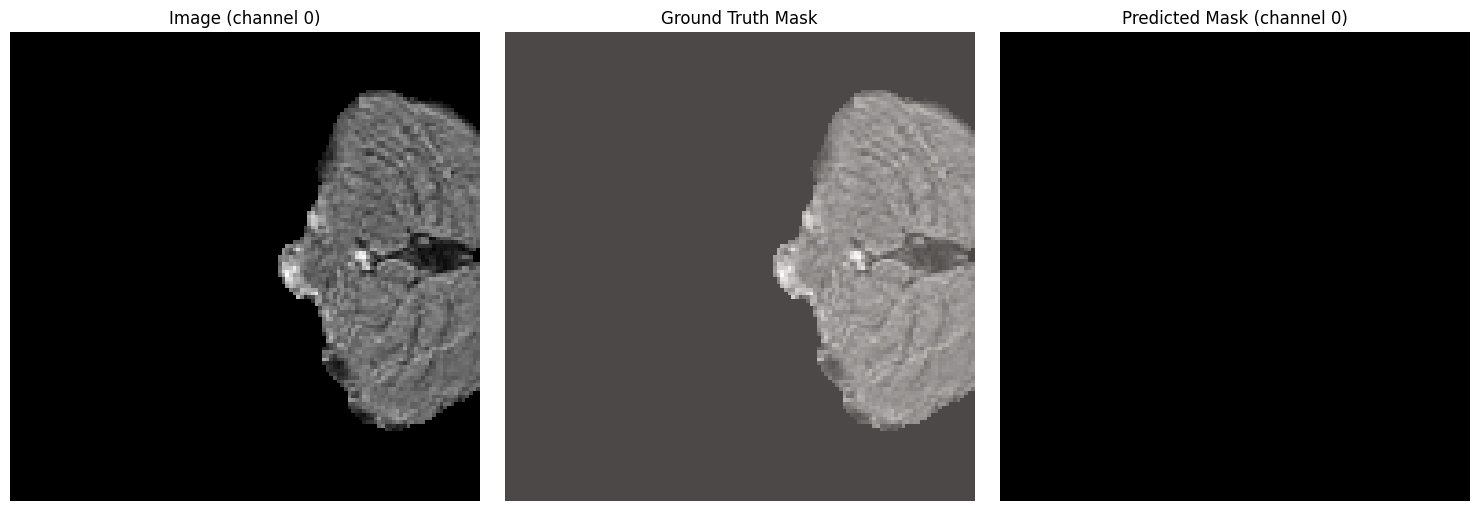

In [14]:

# Plot original image, ground truth mask, predicted mask

fig, axs = plt.subplots(1, 3, figsize=(15, 5))



axs[0].imshow(images[0][0].numpy(), cmap='gray')  # First channel for visualization

axs[0].set_title("Image (channel 0)")


axs[1].imshow(images[0][0].numpy(), cmap='gray')
axs[1].imshow(masks[0][0].numpy(), cmap='Reds', alpha=0.3)
axs[1].set_title("Ground Truth Mask")


# For predicted mask, show channel 0 (or adjust as needed)

axs[2].imshow(preds[0][0].numpy(), cmap='gray')
axs[2].set_title("Predicted Mask (channel 0)")



for ax in axs:

    ax.axis('off')



plt.tight_layout()

print("Mask min:", masks[0][0].min().item())
print("Mask max:", masks[0][0].max().item())
print("Unique mask values:", torch.unique(masks[0][0]))

plt.axis('off')
plt.show()
